# Analiza drzava kroz vrijeme

URL https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv
Data set koji prikazuje podatke po drzavama kroz vrijeme:
- drzava - country,
- godina mjerenja - year,
- broj stanovnik - pop,
- kontinent - continent,
- ocekivani zivotni vijek - lifeExp,
- BDP po stanovniku - gdpPercap


**Pitanje**: Postoji li povezanost izmedu BDP-a po stanovniku i ocekivanog zivotnog vijeka te kako se ti pokayatelji (rezultati analize) mijenjau kroz vrijeme?

Koristiti Pandas, NumPy i Matplotlib ili druge Data Science biblioteka po zelji (trebat ce pojasniti zasto i kako se koristi).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
pd.set_option('display.float_format', '{:,.3f}'.format)

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv')
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,"8,425,333.000",Asia,28.801,779.445
1,Afghanistan,1957,"9,240,934.000",Asia,30.332,820.853
2,Afghanistan,1962,"10,267,083.000",Asia,31.997,853.101
3,Afghanistan,1967,"11,537,966.000",Asia,34.020,836.197
4,Afghanistan,1972,"13,079,460.000",Asia,36.088,739.981


In [29]:
df.shape

(1704, 6)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   str    
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 80.0 KB


In [31]:
df.isna().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

In [32]:
df.describe()

,year,pop,lifeExp,gdpPercap
count,"1,704.000","1,704.000","1,704.000","1,704.000"
mean,"1,979.500","29,601,212.325",59.474,"7,215.327"
std,17.265,"106,157,896.747",12.917,"9,857.455"
min,"1,952.000","60,011.000",23.599,241.166
25%,"1,965.750","2,793,664.000",48.198,"1,202.060"
50%,"1,979.500","7,023,595.500",60.712,"3,531.847"
75%,"1,993.250","19,585,221.750",70.846,"9,325.462"
max,"2,007.000","1,318,683,096.000",82.603,"113,523.133"


In [33]:
df.year.max()

np.int64(2007)

In [34]:
df = df.rename(
    columns={
        'country': 'drzava',
        'year': 'godina',
        'pop': 'stanovnistvo',
        'continent': 'kontinent',
        'lifeExp': 'zivotni_vijek',
        'gdpPercap': 'bdp_po_stanovniku'
    }
)

df.head()

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku
0,Afghanistan,1952,"8,425,333.000",Asia,28.801,779.445
1,Afghanistan,1957,"9,240,934.000",Asia,30.332,820.853
2,Afghanistan,1962,"10,267,083.000",Asia,31.997,853.101
3,Afghanistan,1967,"11,537,966.000",Asia,34.020,836.197
4,Afghanistan,1972,"13,079,460.000",Asia,36.088,739.981


In [35]:
nelogicne_vrijednosti = df[
    (df['stanovnistvo'] <= 0) |
    (df['bdp_po_stanovniku'] <= 0) |
    (df['zivotni_vijek'] <= 0)
]

nelogicne_vrijednosti

,drzava,godina,stanovnistvo,kontinent,zivotni_vijek,bdp_po_stanovniku


In [36]:
df.godina.min(), df.godina.max()

(np.int64(1952), np.int64(2007))

In [37]:
df.kontinent.unique()

<StringArray>
['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
Length: 5, dtype: str

In [38]:
df.drzava.nunique()

142

In [39]:
df.stanovnistvo = df.stanovnistvo.astype(dtype=np.int64)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   drzava             1704 non-null   str    
 1   godina             1704 non-null   int64  
 2   stanovnistvo       1704 non-null   int64  
 3   kontinent          1704 non-null   str    
 4   zivotni_vijek      1704 non-null   float64
 5   bdp_po_stanovniku  1704 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 80.0 KB


In [42]:
zivotni_vijek_po_godini = df.groupby('godina')['zivotni_vijek'].mean()
zivotni_vijek_po_godini

godina
1952   49.058
1957   51.507
1962   53.609
1967   55.678
1972   57.647
1977   59.570
1982   61.533
1987   63.213
1992   64.160
1997   65.015
2002   65.695
2007   67.007
Name: zivotni_vijek, dtype: float64

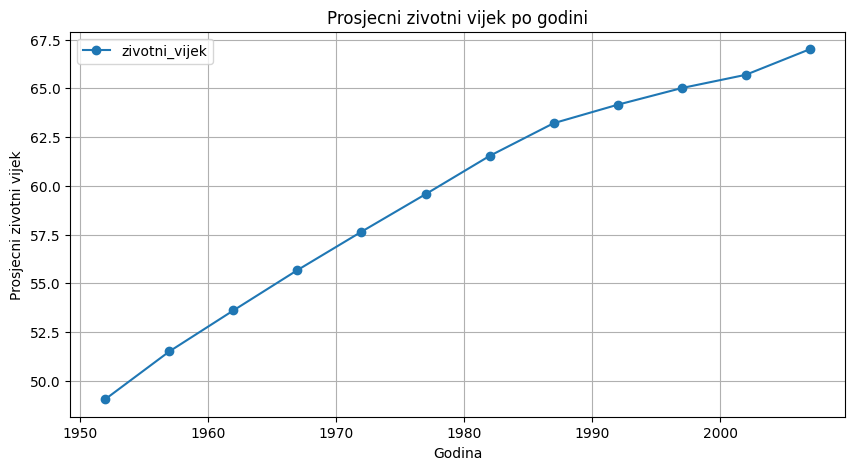

In [47]:
zivotni_vijek_po_godini.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=True,
    title='Prosjecni zivotni vijek po godini'
)

plt.xlabel('Godina')
plt.ylabel('Prosjecni zivotni vijek')
plt.grid(True)
plt.show()

In [51]:
bdp_po_godini = (
    df
    .groupby('godina')['bdp_po_stanovniku']
    .mean()
)

bdp_po_godini

godina
1952    3,725.276
1957    4,299.408
1962    4,725.812
1967    5,483.653
1972    6,770.083
1977    7,313.166
1982    7,518.902
1987    7,900.920
1992    8,158.609
1997    9,090.175
2002    9,917.848
2007   11,680.072
Name: bdp_po_stanovniku, dtype: float64

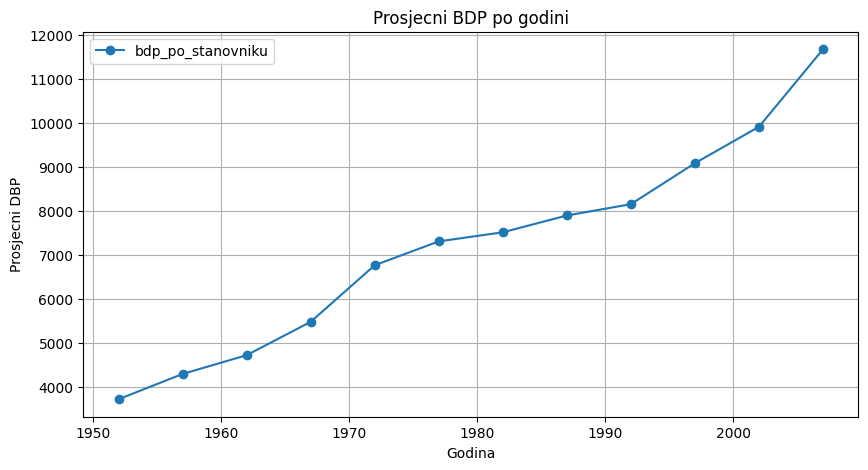

In [52]:
bdp_po_godini.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=True,
    title='Prosjecni BDP po godini'
)

plt.xlabel('Godina')
plt.ylabel('Prosjecni DBP')
plt.grid(True)
plt.show()